# Importing the Required Modules

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, precision_recall_curve,auc

# Loading the Dataset in the form of DataFrame

In [2]:
df=pd.read_csv("/kaggle/input/heartdisease/Heart_Disease_Prediction.csv")

# Taking glimpse of the loaded dataset and extracting some info

In [3]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [4]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [5]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

# Conclusion : We have no null values in the DataFrame

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

# Its time to analyze the dataframe

In [7]:
df['Sex'].unique()

array([1, 0])

# *We have two sex : Female maps with 0 and Male maps with 1

In [8]:
numeric_columns=np.array(df.select_dtypes(include=['number']).columns)
print(f"Number of numeric columns in dataframe : {len(numeric_columns)}")
print(f"Number of columns in the dataframe : {len(df.columns)}")

Number of numeric columns in dataframe : 13
Number of columns in the dataframe : 14


# OOPs: There is one non-numeric column. We need to encode it before feeding in the Logistic Regression Model

In [9]:
df['Heart Disease']=pd.get_dummies(df['Heart Disease'],drop_first=True,dtype=int)
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,0
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,0
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,0
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,0


In [10]:
columns_for_boxplotting=['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
columns_for_boxplotting

['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

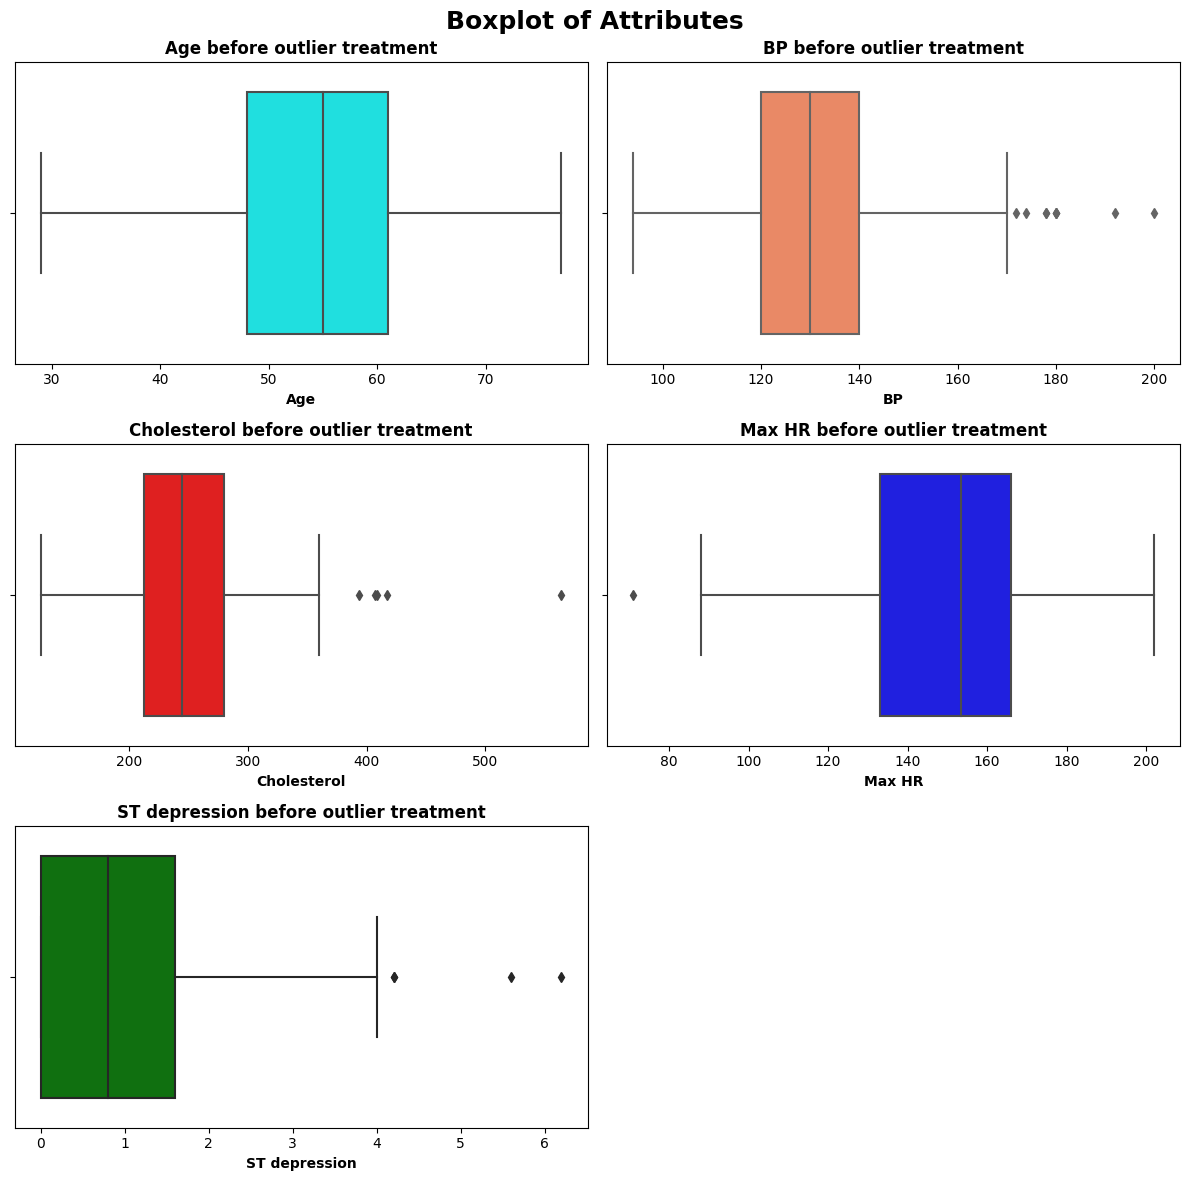

In [11]:
fig,axes=plt.subplots(3,2,figsize=(12,12))
colours=['cyan','coral','red','blue','green']
axes=axes.flatten()
plt.delaxes(axes[-1])

for index in range(len(columns_for_boxplotting)):
    sns.boxplot(x=df[columns_for_boxplotting[index]],ax=axes[index],color=colours[index])
    axes[index].set_xlabel(f'{columns_for_boxplotting[index]}',fontweight='bold')
    axes[index].set_title(f"{columns_for_boxplotting[index]} before outlier treatment", fontweight='bold')

plt.suptitle("Boxplot of Attributes",fontweight='bold',fontsize=18)
plt.tight_layout()
plt.show()

# OMG: Outliers are there. Now we have to remove them!

In [12]:
for index in range(len(columns_for_boxplotting)):
    Q1=df[columns_for_boxplotting[index]].quantile(0.25)
    Q3=df[columns_for_boxplotting[index]].quantile(0.75)
    
    IQR=Q3-Q1

    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR

    df[columns_for_boxplotting[index]]=df[columns_for_boxplotting[index]].clip(lower=lower_limit,upper=upper_limit)
print("Outlier removal accomplished!")

Outlier removal accomplished!


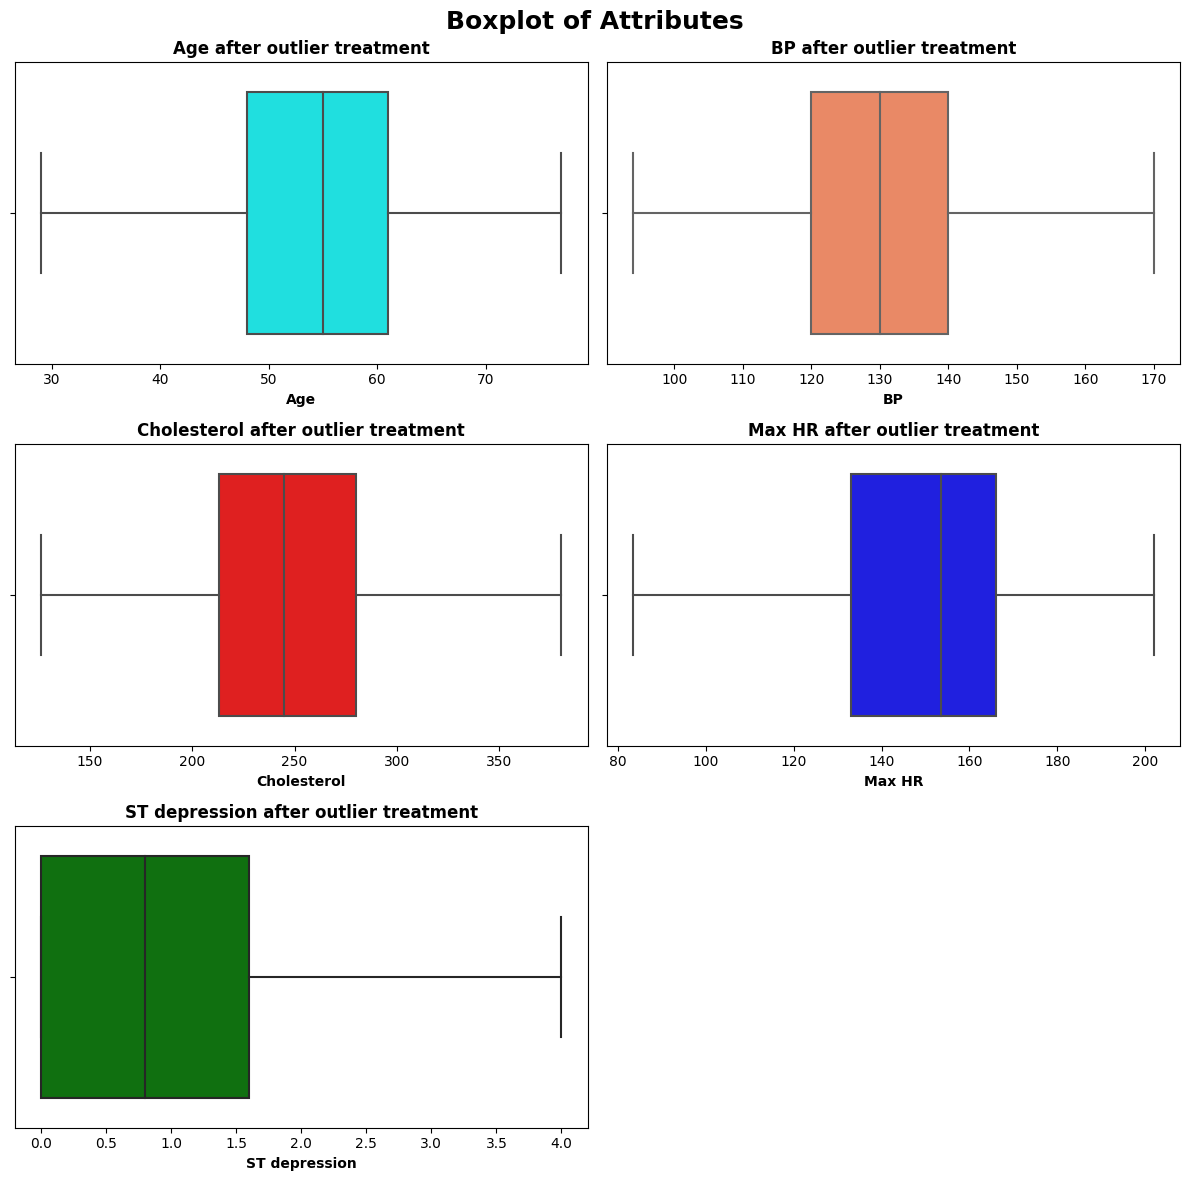

In [13]:
fig,axes=plt.subplots(3,2,figsize=(12,12))
colours=['cyan','coral','red','blue','green']
axes=axes.flatten()
plt.delaxes(axes[-1])

for index in range(len(columns_for_boxplotting)):
    sns.boxplot(x=df[columns_for_boxplotting[index]],ax=axes[index],color=colours[index])
    axes[index].set_xlabel(f'{columns_for_boxplotting[index]}',fontweight='bold')
    axes[index].set_title(f"{columns_for_boxplotting[index]} after outlier treatment", fontweight='bold')

plt.suptitle("Boxplot of Attributes",fontweight='bold',fontsize=18)
plt.tight_layout()
plt.show()

# WOW..It is nice to not to see any points beyond the whiskers

In [14]:
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322.0,0,2,109.0,0,2.4,2,3,3,1
1,67,0,3,115,380.5,0,2,160.0,0,1.6,2,0,7,0
2,57,1,2,124,261.0,0,0,141.0,0,0.3,1,0,7,1
3,64,1,4,128,263.0,0,0,105.0,1,0.2,2,1,7,0
4,74,0,2,120,269.0,0,2,121.0,1,0.2,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,170,199.0,1,0,162.0,0,0.5,1,0,7,0
266,44,1,2,120,263.0,0,0,173.0,0,0.0,1,0,7,0
267,56,0,2,140,294.0,0,2,153.0,0,1.3,2,0,3,0
268,57,1,4,140,192.0,0,0,148.0,0,0.4,2,0,6,0


# One hot Encoding for certain attributes before feeding in the model

In [15]:
df=pd.concat([df,pd.get_dummies(df['Thallium'],prefix='Thallium',drop_first=True,dtype=int)],axis=1)
df=df.drop(columns=['Thallium'])
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Heart Disease,Thallium_6,Thallium_7
0,70,1,4,130,322.0,0,2,109.0,0,2.4,2,3,1,0,0
1,67,0,3,115,380.5,0,2,160.0,0,1.6,2,0,0,0,1
2,57,1,2,124,261.0,0,0,141.0,0,0.3,1,0,1,0,1
3,64,1,4,128,263.0,0,0,105.0,1,0.2,2,1,0,0,1
4,74,0,2,120,269.0,0,2,121.0,1,0.2,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,170,199.0,1,0,162.0,0,0.5,1,0,0,0,1
266,44,1,2,120,263.0,0,0,173.0,0,0.0,1,0,0,0,1
267,56,0,2,140,294.0,0,2,153.0,0,1.3,2,0,0,0,0
268,57,1,4,140,192.0,0,0,148.0,0,0.4,2,0,0,1,0


In [16]:
df=pd.concat([df,pd.get_dummies(df['Chest pain type'],prefix='Chest pain type',drop_first=True,dtype=int)],axis=1)
df=df.drop(columns=['Chest pain type'])
df

,Age,Sex,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Heart Disease,Thallium_6,Thallium_7,Chest pain type_2,Chest pain type_3,Chest pain type_4
0,70,1,130,322.0,0,2,109.0,0,2.4,2,3,1,0,0,0,0,1
1,67,0,115,380.5,0,2,160.0,0,1.6,2,0,0,0,1,0,1,0
2,57,1,124,261.0,0,0,141.0,0,0.3,1,0,1,0,1,1,0,0
3,64,1,128,263.0,0,0,105.0,1,0.2,2,1,0,0,1,0,0,1
4,74,0,120,269.0,0,2,121.0,1,0.2,1,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,170,199.0,1,0,162.0,0,0.5,1,0,0,0,1,0,1,0
266,44,1,120,263.0,0,0,173.0,0,0.0,1,0,0,0,1,1,0,0
267,56,0,140,294.0,0,2,153.0,0,1.3,2,0,0,0,0,1,0,0
268,57,1,140,192.0,0,0,148.0,0,0.4,2,0,0,1,0,0,0,1


In [17]:
df=pd.concat([df,pd.get_dummies(df['EKG results'],prefix='EKG results',drop_first=True,dtype=int)],axis=1)
df=df.drop(columns=['EKG results'])
df

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Heart Disease,Thallium_6,Thallium_7,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2
0,70,1,130,322.0,0,109.0,0,2.4,2,3,1,0,0,0,0,1,0,1
1,67,0,115,380.5,0,160.0,0,1.6,2,0,0,0,1,0,1,0,0,1
2,57,1,124,261.0,0,141.0,0,0.3,1,0,1,0,1,1,0,0,0,0
3,64,1,128,263.0,0,105.0,1,0.2,2,1,0,0,1,0,0,1,0,0
4,74,0,120,269.0,0,121.0,1,0.2,1,1,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,170,199.0,1,162.0,0,0.5,1,0,0,0,1,0,1,0,0,0
266,44,1,120,263.0,0,173.0,0,0.0,1,0,0,0,1,1,0,0,0,0
267,56,0,140,294.0,0,153.0,0,1.3,2,0,0,0,0,1,0,0,0,1
268,57,1,140,192.0,0,148.0,0,0.4,2,0,0,1,0,0,0,1,0,0


In [18]:
df=pd.concat([df,pd.get_dummies(df['Slope of ST'],prefix='Slope of ST',drop_first=True,dtype=int)],axis=1)
df=df.drop(columns=['Slope of ST'])
df

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,Heart Disease,Thallium_6,Thallium_7,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2,Slope of ST_2,Slope of ST_3
0,70,1,130,322.0,0,109.0,0,2.4,3,1,0,0,0,0,1,0,1,1,0
1,67,0,115,380.5,0,160.0,0,1.6,0,0,0,1,0,1,0,0,1,1,0
2,57,1,124,261.0,0,141.0,0,0.3,0,1,0,1,1,0,0,0,0,0,0
3,64,1,128,263.0,0,105.0,1,0.2,1,0,0,1,0,0,1,0,0,1,0
4,74,0,120,269.0,0,121.0,1,0.2,1,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,170,199.0,1,162.0,0,0.5,0,0,0,1,0,1,0,0,0,0,0
266,44,1,120,263.0,0,173.0,0,0.0,0,0,0,1,1,0,0,0,0,0,0
267,56,0,140,294.0,0,153.0,0,1.3,0,0,0,0,1,0,0,0,1,1,0
268,57,1,140,192.0,0,148.0,0,0.4,0,0,1,0,0,0,1,0,0,1,0


In [19]:
df=pd.concat([df,pd.get_dummies(df['Number of vessels fluro'],prefix='Number of vessels fluro',drop_first=True,dtype=int)],axis=1)
df=df.drop(columns=['Number of vessels fluro'])
df

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Heart Disease,Thallium_6,...,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2,Slope of ST_2,Slope of ST_3,Number of vessels fluro_1,Number of vessels fluro_2,Number of vessels fluro_3
0,70,1,130,322.0,0,109.0,0,2.4,1,0,...,0,0,1,0,1,1,0,0,0,1
1,67,0,115,380.5,0,160.0,0,1.6,0,0,...,0,1,0,0,1,1,0,0,0,0
2,57,1,124,261.0,0,141.0,0,0.3,1,0,...,1,0,0,0,0,0,0,0,0,0
3,64,1,128,263.0,0,105.0,1,0.2,0,0,...,0,0,1,0,0,1,0,1,0,0
4,74,0,120,269.0,0,121.0,1,0.2,0,0,...,1,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,170,199.0,1,162.0,0,0.5,0,0,...,0,1,0,0,0,0,0,0,0,0
266,44,1,120,263.0,0,173.0,0,0.0,0,0,...,1,0,0,0,0,0,0,0,0,0
267,56,0,140,294.0,0,153.0,0,1.3,0,0,...,1,0,0,0,1,1,0,0,0,0
268,57,1,140,192.0,0,148.0,0,0.4,0,1,...,0,0,1,0,0,1,0,0,0,0


# Scaling the attributes before feeding it in the model

In [20]:
columns_for_scaling=['Age','BP','Cholesterol','Max HR','ST depression']

# Relationship between attrubutes before scaling

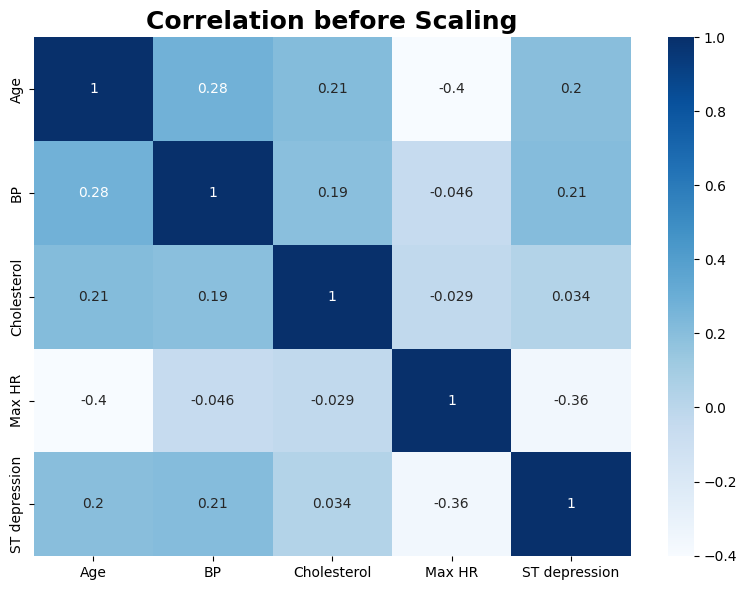

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df[columns_for_scaling].corr(),annot=True,cmap='Blues')
plt.title("Correlation before Scaling",fontweight='bold',fontsize=18)
plt.tight_layout()
plt.show()

# Scaling them

In [22]:
scaler=StandardScaler()
df[columns_for_scaling]=scaler.fit_transform(df[columns_for_scaling])
df

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Heart Disease,Thallium_6,...,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2,Slope of ST_2,Slope of ST_3,Number of vessels fluro_1,Number of vessels fluro_2,Number of vessels fluro_3
0,1.712094,1,-0.057210,1.549364,0,-1.772364,0,1.253423,1,0,...,0,0,1,0,1,1,0,0,0,1
1,1.382140,0,-0.951808,2.784055,0,0.447222,0,0.519115,0,0,...,0,1,0,0,1,1,0,0,0,0
2,0.282294,1,-0.415049,0.261908,0,-0.379683,0,-0.674136,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1.052186,1,-0.176490,0.304119,0,-1.946450,1,-0.765924,0,0,...,0,0,1,0,0,1,0,1,0,0
4,2.152032,0,-0.653609,0.430754,0,-1.250109,1,-0.765924,0,0,...,1,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,-0.267629,1,2.328384,-1.046654,1,0.534264,0,-0.490559,0,0,...,0,1,0,0,0,0,0,0,0,0
266,-1.147506,1,-0.653609,0.304119,0,1.012998,0,-0.949501,0,0,...,1,0,0,0,0,0,0,0,0,0
267,0.172309,0,0.539188,0.958400,0,0.142573,0,0.243750,0,0,...,1,0,0,0,1,1,0,0,0,0
268,0.282294,1,0.539188,-1.194395,0,-0.075034,0,-0.582347,0,1,...,0,0,1,0,0,1,0,0,0,0


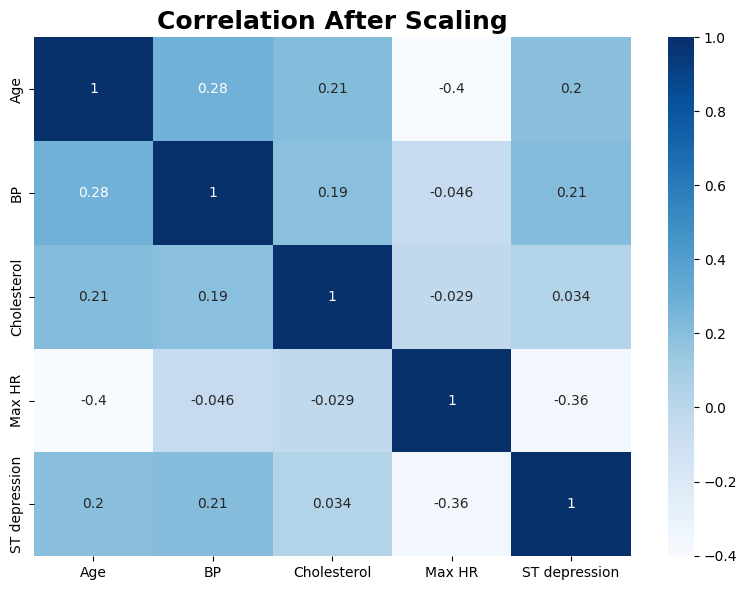

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df[columns_for_scaling].corr(),annot=True,cmap='Blues')
plt.title("Correlation After Scaling",fontweight='bold',fontsize=18)
plt.tight_layout()
plt.show()

# Scaling done!

In [24]:
df

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Heart Disease,Thallium_6,...,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,EKG results_2,Slope of ST_2,Slope of ST_3,Number of vessels fluro_1,Number of vessels fluro_2,Number of vessels fluro_3
0,1.712094,1,-0.057210,1.549364,0,-1.772364,0,1.253423,1,0,...,0,0,1,0,1,1,0,0,0,1
1,1.382140,0,-0.951808,2.784055,0,0.447222,0,0.519115,0,0,...,0,1,0,0,1,1,0,0,0,0
2,0.282294,1,-0.415049,0.261908,0,-0.379683,0,-0.674136,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1.052186,1,-0.176490,0.304119,0,-1.946450,1,-0.765924,0,0,...,0,0,1,0,0,1,0,1,0,0
4,2.152032,0,-0.653609,0.430754,0,-1.250109,1,-0.765924,0,0,...,1,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,-0.267629,1,2.328384,-1.046654,1,0.534264,0,-0.490559,0,0,...,0,1,0,0,0,0,0,0,0,0
266,-1.147506,1,-0.653609,0.304119,0,1.012998,0,-0.949501,0,0,...,1,0,0,0,0,0,0,0,0,0
267,0.172309,0,0.539188,0.958400,0,0.142573,0,0.243750,0,0,...,1,0,0,0,1,1,0,0,0,0
268,0.282294,1,0.539188,-1.194395,0,-0.075034,0,-0.582347,0,1,...,0,0,1,0,0,1,0,0,0,0


# Splitting the dataset into test and train set

In [25]:
y=df['Heart Disease']

X_train,X_test=train_test_split(df,test_size=0.25,random_state=42,stratify=y)

Y_train=X_train['Heart Disease']
X_train=X_train.drop(columns=['Heart Disease'])

Y_test=X_test['Heart Disease']
X_test=X_test.drop(columns=['Heart Disease'])

In [26]:
Y_test.value_counts()

Heart Disease
0    38
1    30
Name: count, dtype: int64

In [27]:
Y_train.value_counts()

Heart Disease
0    112
1     90
Name: count, dtype: int64

# Checking stratify working efficiency

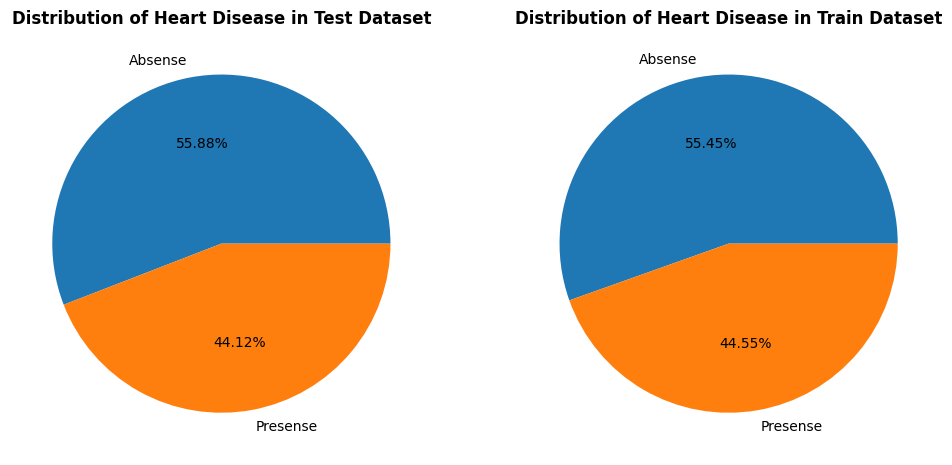

In [28]:
fig,axes=plt.subplots(1,2,figsize=(12,8))

axes[0].pie(Y_test.value_counts(),labels=['Absense','Presense'],autopct= '%.2f%%')
axes[0].set_title("Distribution of Heart Disease in Test Dataset",fontweight='bold')

axes[1].pie(Y_train.value_counts(),labels=['Absense','Presense'],autopct= '%.2f%%')
axes[1].set_title("Distribution of Heart Disease in Train Dataset",fontweight='bold')
plt.show()

# Efficiency is very close to 1. Great!

# Training the model

In [29]:
model=LogisticRegression(C=0.85,max_iter=1500)
model.fit(X_train,Y_train)

LogisticRegression(C=0.85, max_iter=1500)

# Predicting with the trained model

In [30]:
Y_predicted=model.predict(X_test)

# Comparing the original and predicted status

In [31]:
dataframe=pd.DataFrame({'Original_Status': Y_test,'Predicted_Status': Y_predicted}).reset_index().rename(columns={'index':'Patient_Identifier'})
dataframe.head(10)

,Patient_Identifier,Original_Status,Predicted_Status
0,231,1,1
1,122,1,1
2,266,0,0
3,213,1,1
4,166,0,0
5,234,0,1
6,149,0,0
7,38,0,0
8,97,1,1
9,49,1,1


# Evaluating the model built so

In [32]:
print(f"The accuracy of the model is : {round(accuracy_score(Y_test,Y_predicted)*100,2)}")

The accuracy of the model is : 88.24


In [33]:
print(f"The confusion matrix is : \n{confusion_matrix(Y_test,Y_predicted)}")

The confusion matrix is : 
[[33  5]
 [ 3 27]]


In [34]:
print(f"The classification report is : \n{classification_report(Y_test,Y_predicted)}")

The classification report is : 
              precision    recall  f1-score   support

           0       0.92      0.87      0.89        38
           1       0.84      0.90      0.87        30

    accuracy                           0.88        68
   macro avg       0.88      0.88      0.88        68
weighted avg       0.88      0.88      0.88        68



# Visualizing the report of the model evaluation

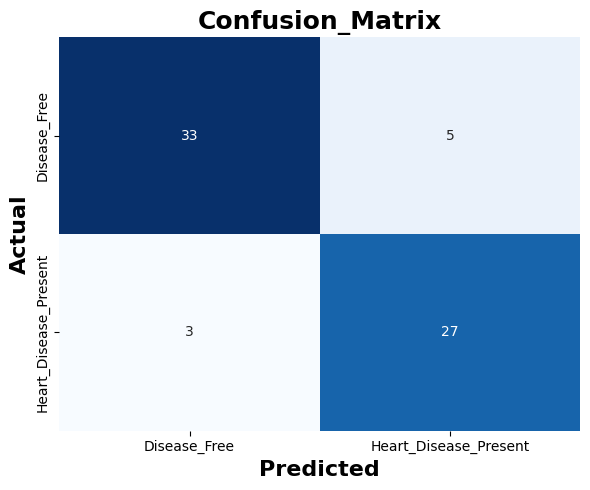

In [35]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(Y_test,Y_predicted),annot=True,cmap='Blues',cbar=False,
           xticklabels=['Disease_Free','Heart_Disease_Present'],yticklabels=['Disease_Free','Heart_Disease_Present'])
plt.xlabel("Predicted",fontweight='bold',fontsize=16)
plt.ylabel("Actual",fontweight='bold',fontsize=16)
plt.title("Confusion_Matrix",fontweight='bold',fontsize=18)
plt.tight_layout()
plt.show()

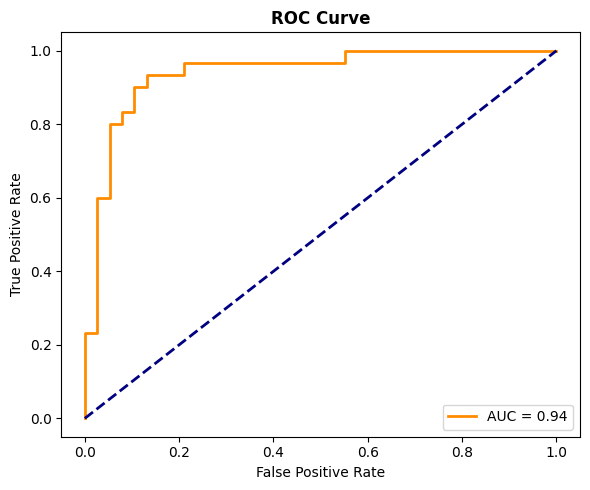

In [36]:
Y_pred_proba = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.title("ROC Curve",fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

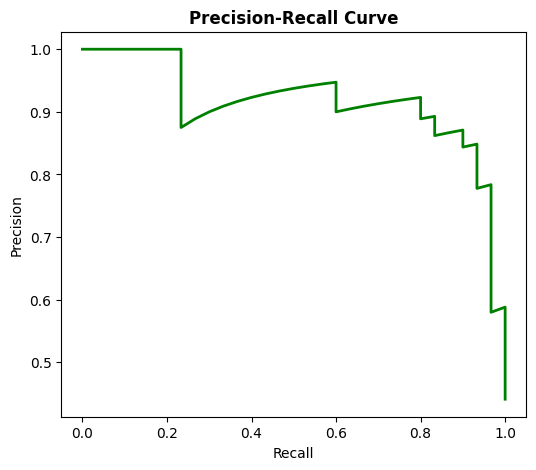

In [37]:
precision, recall, thresholds = precision_recall_curve(Y_test, Y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color="green", lw=2)
plt.title("Precision-Recall Curve",fontweight='bold')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Thank You :)